2026-01-20 14:21:11,606	INFO worker.py:2007 -- Started a local Ray instance.
/homes/gws/tiernan7/Projects/DSD-CRNN/venv/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


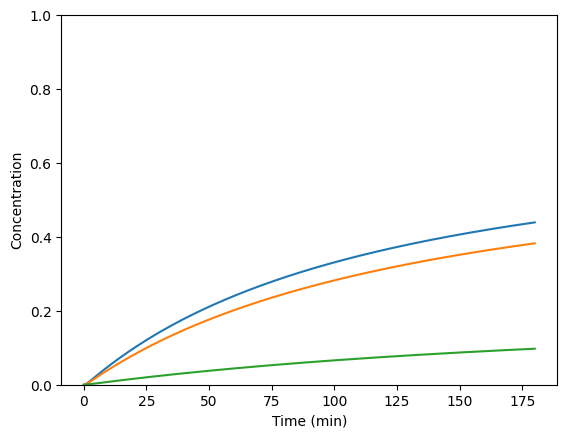

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn  # Import neural network module
import torch.optim as optim  # Import optimization module
import src
from src.data.synthetic_data import SyntheticDataGenerator
from src.data.dataset import KineticDataset, Normalize
from src.data.data_loader import get_data_loaders, load_data
from src.models.crnn import CRNN
from src.models.loss_fn import RangeNormalizedMAE, RangeNormalizedMSE
import ray
from ray import tune
from ray.tune import Checkpoint
from ray.tune.schedulers import ASHAScheduler
from src.models.train_tune import CRNN_tune, test_accuracy
import logging


if not ray.is_initialized():
    ray.init(include_dashboard=False, log_to_driver=False)


# For one step reaction
y0 = {
    'S_1' : (10, 100),
    'S_2' : (10, 100),
    'S_3' : (0, 0),
    'S_4' : (0, 0),
    'S_out' : (0, 0),
}
ks = [2e3*1e-9, 2e7*1e-9]  # M^-1 s^-1 converted to nM^-1 s^-1

time_hours = 3 #hours
t_end = time_hours * 3600  # seconds
E_bounds = (1e-3, 1e-1)


data_gen = SyntheticDataGenerator(
    mechanism='one_step_1latent',
    reaction_rates=ks,
    initial_concentration_ranges=y0,
    noise_level=0,
    t_end=t_end,
    n_timepoints = t_end//30,  # every 30 seconds
    seed=42,
    E_bounds=E_bounds,
)

batch_size = 3
batch = data_gen.generate_batch(batch_size)
norm = Normalize(max_concentration=torch.max(batch["c0"]))

ds = KineticDataset(batch, transform=norm)

# Visualize kinetics for each sample on a single plot
t = ds.get_t().numpy()

for i in range(batch_size):
    sample = ds[i]
    y = sample['y'].numpy()
    plt.plot(t/60, y, label=f'Sample {i}')
plt.xlabel('Time (min)')
plt.ylabel('Concentration')
plt.ylim(0, 1)
plt.show()

# Fresh run

In [2]:
#clean results directory
import shutil
import os
shutil.rmtree("/homes/gws/tiernan7/Projects/DSD-CRNN/ray_results/crnn_tune", ignore_errors=True)
os.makedirs("/homes/gws/tiernan7/Projects/DSD-CRNN/ray_results", exist_ok = True)

In [3]:

# Constant hyperparameters
epochs = 100000
num_reactions = 2
num_samples = 50

config = {
    "lr": tune.loguniform(1e-4, 1e-1),
    'epochs': epochs,
    'num_reactions': num_reactions
}

# Configure the ASHA scheduler
scheduler = ASHAScheduler(
    metric="val_loss",
    mode="min",
    max_t=epochs,
    grace_period=10,
    reduction_factor=3,
)

#Model to tune 
trainable = tune.with_parameters(CRNN_tune, dataset=ds)


tuner = tune.Tuner(
    trainable,
    param_space=config,
    tune_config=tune.TuneConfig(
        num_samples=num_samples,
        scheduler=scheduler,
    ),
    run_config=tune.RunConfig(
        name="crnn_tune",
        storage_path="/homes/gws/tiernan7/Projects/DSD-CRNN/ray_results"
    ),
)


results = tuner.fit()
best = results.get_best_result(metric="val_loss", mode="min")
print("Best config:", best.config)
print("Best val_loss:", best.metrics["val_loss"])


2026-01-20 15:49:12,073	WARNING tune.py:219 -- Stop signal received (e.g. via SIGINT/Ctrl+C), ending Ray Tune run. This will try to checkpoint the experiment state one last time. Press CTRL+C (or send SIGINT/SIGKILL/SIGTERM) to skip. 
2026-01-20 15:49:12,239	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/homes/gws/tiernan7/Projects/DSD-CRNN/ray_results/crnn_tune' in 0.1641s.
2026-01-20 15:49:22,272	INFO tune.py:1041 -- Total run time: 5266.88 seconds (5256.64 seconds for the tuning loop).
2026-01-20 15:49:22,273	WARNING tune.py:1056 -- Experiment has been interrupted, but the most recent state was saved.
Resume experiment with: Tuner.restore(path="/homes/gws/tiernan7/Projects/DSD-CRNN/ray_results/crnn_tune", trainable=...)


Best config: {'lr': 0.06872148963456706, 'epochs': 100000, 'num_reactions': 2}
Best val_loss: 0.001703230431303382


# Restart

In [ ]:
# Constant hyperparameters
epochs = 100000
num_reactions = 2
num_trials = 10

config = {
    "l1": tune.loguniform(1e-2, 1e1),
    "lr": tune.loguniform(1e-4, 1e-1),
    'epochs': epochs,
    'num_reactions': num_reactions
}

# 2. Configure the ASHA scheduler
scheduler = ASHAScheduler(
    metric="val_loss",
    mode="min",
    max_t=epochs,
    grace_period=10,
    reduction_factor=3,
)

trainable = tune.with_parameters(CRNN_tune, dataset=ds)


# if need to restart from previous
tuner = tune.Tuner.restore(
    "/homes/gws/tiernan7/ray_results/crnn_tune",
    trainable=trainable,   
)

results = tuner.fit()
best = results.get_best_result(metric="val_loss", mode="min")
print("Best config:", best.config)
print("Best val_loss:", best.metrics["val_loss"])


ValueError: Invalid `trainable` input to `Tuner.restore()`. To fix this error, pass in the same trainable that was used to initialize the Tuner. Got a trainable with identifier 'CRNN_tune' but expected 'train_CRNN'.